## **Project - Second Draft**

### Map with Circles (FRP as Size, Brightness as Colour)

#### **Content**
1. Load important packages and map key
2. Fetch the Data as in Draft 1
3. convert to gdf
4. Look at FRP (Intensity) Data -> do some data handling, rescaling etc. if necessary
5. Filter out data according to confidence -> all fires with low confidence will not be included in the map
6. Create Map with manipulated FRP Data and bright_ti4 as colour
7. If not too difficult, use D/N for circle circumference

Source for Attribute Table: https://www.earthdata.nasa.gov/data/instruments/viirs/viirs-i-band-375-m-active-fire-data

#### **Notes**

* Make different histograms for different sensors to display the sensitivity
* 

### **Important Libraries and Map Key** 

In [2]:

# import important packages
import requests
import pandas as pd
import geopandas as gpd
import time
import matplotlib.pyplot as plt
import folium
import contextily
import cmcrameri


from cartopy import crs as ccrs
from geodatasets import get_path

In [3]:
# test my MAP_KEY

map_key = "ea49e5fe6beaf3a00954c71727386596"

import pandas as pd
import requests
key_url = f"https://firms.modaps.eosdis.nasa.gov/mapserver/mapkey_status/?map_key={map_key}"
try:
  response = requests.get(key_url)

  if response.status_code == 200:
    data = response.json()
    df = pd.Series(data)
    display(df)
  else:
    print(f"Error in the query: HTTP {response.status_code}")
    print(response.text)

  
except Exception as e:
  # possible error, wrong MAP_KEY value, check for extra quotes, missing letters
  print (f"There is an issue with the query: {e}\n try in your browser: {key_url}")
  


transaction_limit             5000
current_transactions             0
transaction_interval    10 minutes
dtype: object

### **Fetch Data as in Draft 1**

In [4]:

import requests
import time
import datetime 
import geopandas as gpd
import pandas as pd
from io import StringIO

map_key = "ea49e5fe6beaf3a00954c71727386596"

# define the number of days to fetch data for (going back x days from today)
days = 5


# define coordinates for South America  (min_lon, min_lat, max_lon, max_lat
region_coords = "-81.5,-55.0,-35.0,12.5"

# define sensor and products
sensor = "VIIRS_NOAA20_NRT"
product = "fire"

# define API endpoint url

api_url = f"https://firms.modaps.eosdis.nasa.gov/api/area/csv/{map_key}/{sensor}/{region_coords}/{days}"


# fetch the data

response = requests.get(api_url)

# check the status and extract the data
if response.status_code == 200: 
    print("Request successful\n")

    # read url and create dataframe
    df_fire = pd.read_csv(StringIO(response.text)) # for only 1 api request instead of 2

    # sample only 1000 / 500 / 300 rows; so my computer does not crash and I can develop my map
    # to create a good heat map, I use 1000 rows
    #if len(df_fire) > 1000:
       # df_fire = df_fire.sample(1000, random_state=42)

    print(f"\n Data download successful! {len(df_fire)} fires found")  ## NA handling??
    display(df_fire.head(6))

    # option: include a saving option if wanted
    #df_fire.to_csv("firms_data_startdate_enddate.csv", index=False) wieso index = false??

elif response.status_code == 404:
    print(f"Error 404: Page not found")

elif response.status_code == 401:
    print(f"Error 401: Invalid API-Key, please check map-key")

elif response.status_code == 400:
    print(f"Error 400: Wrong parameters, please check input parameters.")


else: 
    print(f"Request failed: Status {response.status_code}")
    print(response.text)





Request successful


 Data download successful! 8133 fires found


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight
0,-21.09019,-41.24693,304.74,0.51,0.66,2026-05-09,310,N20,VIIRS,n,2.0NRT,289.71,1.23,N
1,-21.08911,-41.25149,311.94,0.51,0.66,2026-05-09,310,N20,VIIRS,n,2.0NRT,289.92,1.23,N
2,-20.55203,-43.76801,302.23,0.76,0.77,2026-05-09,310,N20,VIIRS,n,2.0NRT,286.83,4.31,N
3,-20.55008,-43.77567,311.96,0.76,0.77,2026-05-09,310,N20,VIIRS,n,2.0NRT,286.39,3.49,N
4,-20.25288,-40.23982,316.07,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.62,2.59,N
5,-20.25187,-40.24426,311.30,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.16,2.11,N


### **Make gdf and Make Geometries** 

In [5]:

gdf_fire = gpd.GeoDataFrame(
    df_fire, 
    geometry=gpd.points_from_xy(
        df_fire.longitude, df_fire.latitude),
        
        crs="EPSG:4326")

gdf_fire.head()


,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry
0,-21.09019,-41.24693,304.74,0.51,0.66,2026-05-09,310,N20,VIIRS,n,2.0NRT,289.71,1.23,N,POINT (-41.24693 -21.09019)
1,-21.08911,-41.25149,311.94,0.51,0.66,2026-05-09,310,N20,VIIRS,n,2.0NRT,289.92,1.23,N,POINT (-41.25149 -21.08911)
2,-20.55203,-43.76801,302.23,0.76,0.77,2026-05-09,310,N20,VIIRS,n,2.0NRT,286.83,4.31,N,POINT (-43.76801 -20.55203)
3,-20.55008,-43.77567,311.96,0.76,0.77,2026-05-09,310,N20,VIIRS,n,2.0NRT,286.39,3.49,N,POINT (-43.77567 -20.55008)
4,-20.25288,-40.23982,316.07,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.62,2.59,N,POINT (-40.23982 -20.25288)


### **Analyse FRP Data**

1. Search for NAs
2. Make a histogram and look how the distribution is 
3. If very skewed, make a sqrt transformation 
   - I do this because I don't want the extreme values to dominate my map; extremely little fires are not very well visible whereas super big fires take up the entire map
   - take square root of magnitude to be mapped (here FRP)
   - see Lecture 5 from GEO123, slide Nr. 25



In [6]:
# search for NAs
gdf_fire.info() # .info() provides row counts, missing values and dtypes of every column

# could also sum up NAs per column with int(gdf_fire["fire_map1.html"].isna().sum())if wanted

int(gdf_fire["frp"].isna().sum())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 8133 entries, 0 to 8132
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   latitude    8133 non-null   float64 
 1   longitude   8133 non-null   float64 
 2   bright_ti4  8133 non-null   float64 
 3   scan        8133 non-null   float64 
 4   track       8133 non-null   float64 
 5   acq_date    8133 non-null   str     
 6   acq_time    8133 non-null   int64   
 7   satellite   8133 non-null   str     
 8   instrument  8133 non-null   str     
 9   confidence  8133 non-null   str     
 10  version     8133 non-null   str     
 11  bright_ti5  8133 non-null   float64 
 12  frp         8133 non-null   float64 
 13  daynight    8133 non-null   str     
 14  geometry    8133 non-null   geometry
dtypes: float64(7), geometry(1), int64(1), str(6)
memory usage: 1.1 MB


0

Text(0.5, 0, 'FRP [W/m²]')

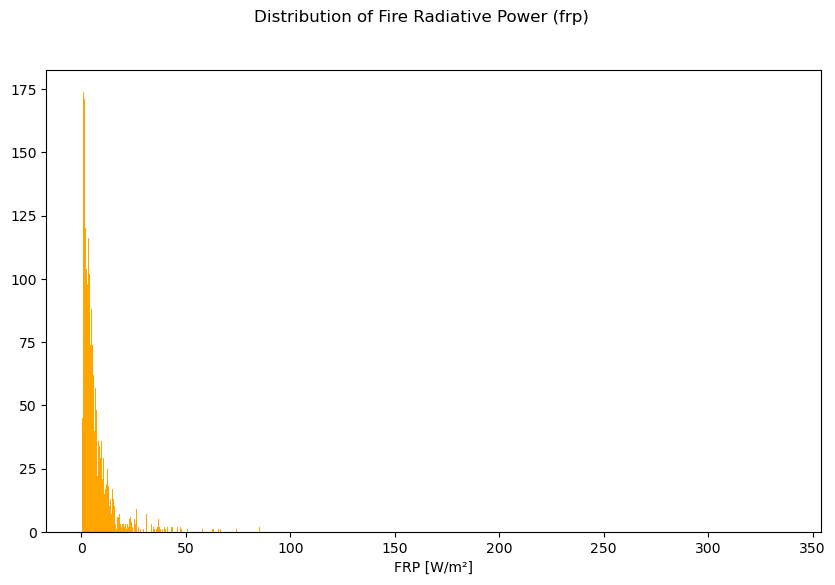

In [7]:
## make histogram of "frp" column -> how is the data distributed?

fig, ax = plt.subplots(figsize=(10,6))

ax.hist(
    gdf_fire["frp"].dropna(),
    bins=3000,
    color = "orange"
)
fig.suptitle("Distribution of Fire Radiative Power (frp)", fontsize = 12)
ax.set_xlabel("FRP [W/m²]")

In [8]:
# filter for max and min value of frp, add float to only get the number
max_value = float(gdf_fire["frp"].max())
min_value = float(gdf_fire["frp"].min())

print(f"The maximum value of FRP is {max_value} W/m² and the minimum value of FRP is {min_value} W/m².")
print(f"The distribution of the values is heavily right-skewed. ")

The maximum value of FRP is 337.34 W/m² and the minimum value of FRP is 0.05 W/m².
The distribution of the values is heavily right-skewed. 


In [9]:
# get mean and median values for frp
mean_value = float(gdf_fire["frp"].mean())
median_value = float(gdf_fire["frp"].median())

print(f"The mean value of FRP is {mean_value:.3f} W/m² and the median value of FRP is {median_value} W/m².")

The mean value of FRP is 6.923 W/m² and the median value of FRP is 4.31 W/m².


#### **Results of Visualisation**
-> Attention these change, should not include this as Markdown in the final script

---------------------------------------------
As visible in the histogram, the distribution is heavily right-skewed. The minimum value is 0.05 W/m² and the maximum value is 328.12 W/m². Furthermore, the mean is 7.187 W/m² (rounded) and the median 4.52 W/m². Thus, because many fires are small, it makes sense to scale them.

##### **Scaling of FRP-Value -> keep for later, if other visualisation does not work**

Take square root of FRP Value

add generated values to data frame gdf_fire

----------------------------------------------
IGNORE THIS NEXT LINE OF CODE
will try to scale the objects directly in the map visualisation


In [ ]:
# create column with square root of frp

#gdf_fire["frp_sqrt"] = gdf_fire["frp"]


#### **Convert Brightness Values from Kelvin to Degrees Celsius °C**

0 Kelvin = -273.15 °C

Conversion: °C = °K - 273.15

apply this on column bright_ti4

In [10]:
gdf_fire["bright_ti4_celsius"] = gdf_fire["bright_ti4"] - 273.15

gdf_fire.head(10)

,latitude,longitude,bright_ti4,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_ti5,frp,daynight,geometry,bright_ti4_celsius
0,-21.09019,-41.24693,304.74,0.51,0.66,2026-05-09,310,N20,VIIRS,n,2.0NRT,289.71,1.23,N,POINT (-41.24693 -21.09019),31.59
1,-21.08911,-41.25149,311.94,0.51,0.66,2026-05-09,310,N20,VIIRS,n,2.0NRT,289.92,1.23,N,POINT (-41.25149 -21.08911),38.79
2,-20.55203,-43.76801,302.23,0.76,0.77,2026-05-09,310,N20,VIIRS,n,2.0NRT,286.83,4.31,N,POINT (-43.76801 -20.55203),29.08
3,-20.55008,-43.77567,311.96,0.76,0.77,2026-05-09,310,N20,VIIRS,n,2.0NRT,286.39,3.49,N,POINT (-43.77567 -20.55008),38.81
4,-20.25288,-40.23982,316.07,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.62,2.59,N,POINT (-40.23982 -20.25288),42.92
5,-20.25187,-40.24426,311.30,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.16,2.11,N,POINT (-40.24426 -20.25187),38.15
6,-20.24808,-40.23389,312.81,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.54,8.08,N,POINT (-40.23389 -20.24808),39.66
7,-20.24709,-40.23824,314.24,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.67,8.08,N,POINT (-40.23824 -20.24709),41.09
8,-20.24608,-40.24269,326.55,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.54,4.82,N,POINT (-40.24269 -20.24608),53.40
9,-20.24229,-40.23233,335.14,0.46,0.64,2026-05-09,310,N20,VIIRS,n,2.0NRT,290.57,8.08,N,POINT (-40.23233 -20.24229),61.99


### **Filter Data for Confindence Values without low confidence** 
The confidence attribute identifies the quality of every hotspot/fire pixel. It accounts for sun glint contamination during the day. Areas with low confidence (l) are associated with areas of sun glint. Nominal confidence pixels (n) are free of potential sun glint contamination. Pixels showing high confidence (h) are indicative for saturated day or nighttime pixels.

l: low

n: nominal

h: high



In [11]:
gdf_fire_reduced = gdf_fire[(gdf_fire["confidence"]!="l")].copy()
gdf_fire_reduced.head(10)

# check if no low confidence fires are included

gdf_fire_reduced["confidence"].unique()

#other method
#gdf_fire_reduced[gdf_fire_reduced["confidence"] == "l"]


<ArrowStringArray>
['n', 'h']
Length: 2, dtype: str

### **Create Map**

In [ ]:
import numpy as np
import branca.colormap as cm
from folium.plugins import MarkerCluster

# initialize basemap centerd on South America as in Draft 1

map1_draft2 = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter"
)

# add cluster (maybe take this out later)
marker_cluster = MarkerCluster(name="Scaled Fire Detections Cluster").add_to(map1_draft2)

# define colormap for marker

colormap = cm.linear.YlOrRd_09.scale(
    gdf_fire_reduced["bright_ti4_celsius"].min(),
    gdf_fire_reduced["bright_ti4_celsius"].max()
)


for idx, row in gdf_fire_reduced.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    brightness = int(row["bright_ti4_celsius"])
    color = colormap(brightness)

    tooltip_text = f"Brightness: {brightness} °C"

    # mathematical scaling of the marker size based on the "frp_sqrt" column
    # base size of 14px plus an increase based on the square root of frp (as done in Lesson8)
    icon_size = 14 + (np.sqrt(row["frp"])*3)

    # define color of circle border; fire detected at night = blue, fire detected during day = white
    if row["daynight"] == "N":
        border_color = "blue" 

    else: border_color = "white"

    # add a custom CSS to draw a circle
    icon_html = f"""
    <div style="
    font-size: {icon_size}px;
    color: {color}; 
    background: {color};
    border-radius: 50%;
    width: {icon_size}px;
    height: {icon_size}px;
    display: flex;
    align-items: center;
    justify-content: center;
    border: 2px solid {border_color};
    opacity: 0.8;
    ">
    < i class="fa fa-fire" style = "color: {color};"></i>
    </div>
    """


    # apply the custom HTML using DivIcon
    folium.Marker(
        location = [lat, lon],
        icon = folium.DivIcon(
            html = icon_html,
            icon_size = (icon_size, icon_size),
            icon_anchor = (icon_size/2, icon_size/2),   
        ),
        tooltip = tooltip_text,
    ).add_to(marker_cluster)

# add interactive layer control
folium.LayerControl().add_to(map1_draft2)

# save map because I cannot display it in VS Code
map1_draft2.save("fire_map_scaled_markers.html")







    

In [ ]:
import numpy as np
import branca.colormap as cm
from folium.plugins import MarkerCluster

# initialize basemap centerd on South America as in Draft 1

map1_draft2 = folium.Map(location = [-15, -60], zoom_start = 3, tiles = "CartoDB DarkMatter"
)

# add cluster (maybe take this out later)
marker_cluster = MarkerCluster(name="Scaled Fire Detections Cluster").add_to(map1_draft2)

# define colormap for marker

colormap = cm.linear.YlOrRd_09.scale(
    gdf_fire_reduced["bright_ti4_celsius"].min(),
    gdf_fire_reduced["bright_ti4_celsius"].max()
)

# make quartiles for brightness so it is a thematic map (?? check with GEO123)

for idx, row in gdf_fire_reduced.iterrows():
    lat = row.geometry.y
    lon = row.geometry.x
    brightness = int(row["bright_ti4_celsius"])
    color = colormap(brightness)

    tooltip_text = f"Brightness: {brightness} °C"

    # mathematical scaling of the marker size based on the "frp_sqrt" column
    # base size of 14px plus an increase based on the square root of frp (as done in Lesson8)
    icon_size = 25 + (np.sqrt(row["frp"])*3)

    # define color of circle border; fire detected at night = blue, fire detected during day = white
    if row["daynight"] == "N":
        border_color = "blue" 

    else: border_color = "white"

    # add a custom CSS to draw a circle
    icon_html = f"""
    <div style="
    color: {color}; 
    background: {color};
    border-radius: 50%;
    width: {icon_size}px;
    height: {icon_size}px;
    display: flex;
    align-items: center;
    justify-content: center;
    border: 2px solid {border_color};
    opacity: 0.8;
    ">
    <i class="fa fa-fire" style = "color: {color};"></i>
    </div>
    """


    # apply the custom HTML using DivIcon
    folium.Marker(
        location = [lat, lon],
        icon = folium.DivIcon(
            html = icon_html,
            icon_size = (icon_size, icon_size),
            icon_anchor = (icon_size/2, icon_size/2),   
        ),
        tooltip = tooltip_text,
    ).add_to(marker_cluster)


legend_html = """
<div style = "position: fixed;
bottom: 50px; 
left: 50px;
width: 150px; 
height: 180px;
background-color: white;
z-index:9999;
font-size:14px;
padding: 10px;
border: 2px solid grey;
">

<b>Fire Brightness (°C) Legend</b><br>
<i style="background:#ffffcc;width:20px;height:10px;float:left;margin-right:8px;"></i> Low<br>

<i style="background:#feb24c;width:20px;height:10px;float:left;margin-right:8px;"></i> Medium<br>

<i style="background:#f03b20;width:20px;height:10px;float:left;margin-right:8px;"></i> High<br>

<i style="background:#bd0026;width:20px;height:10px;float:left;margin-right:8px;"></i> Extreme

</div>
"""

map1_draft2.get_root().html.add_child(folium.Element(legend_html))

# add interactive layer control
folium.LayerControl().add_to(map1_draft2)

# save map because I cannot display it in VS Code
map1_draft2.save("fire_map_scaled_markers.html")







    

#### **Notes**

Fire Points are maybe too big? They cover probably a larger area right now than they cover in reality -> but otherwise they are not visible

add a meter bar

add a northern arrow?